# Data Exploration Tutorial

In this notebook we explore the dataset of audio recordings collected and annotated by you.

You will learn how to:
- Set up an environment
- Load and inspect metadata and annotations using **pandas**
- Explore audio features
- Load and inspect raw audio with **librosa**

## 1. Environment Setup (5 minutes)

**Set up your conda environment:**

Before we start, create a dedicated conda environment. If you did not do so yet, download and install [miniconda](https://www.anaconda.com/docs/getting-started/miniconda/install). Restart your terminal and run the following commands:

```bash
# 1. Create a new conda environment 'mlpc2026' with Python 3.12
conda create -y -n mlpc2026 -c conda-forge python=3.12 numpy pandas matplotlib jupyterlab librosa

# 2. Activate the environment
conda activate mlpc2026
```

Activate the conda environment via `conda activate mlpc2026`.
Start jupyterhub via `python -m jupyterlab`.

**Tips:** 
- Always use a dedicated environment per project to avoid dependency conflicts. 
- If you want to perform clustering or dimensionality reduction, we recommend installing `scikit-learn` as well.

**Run the cell below** to check your setup.

In [1]:
import os
import math

# if you've setup your environment, importing these libraries should not throw an error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH_TO_DATASET = 'MLPC2026_dataset_development'

assert os.path.exists(PATH_TO_DATASET), "The dataset folder 'MLPC2026_dataset' does not exist; download the data set and extract its content."
assert os.path.exists(os.path.join(PATH_TO_DATASET, 'annotations.csv')), "The file 'MLPC2026_dataset/annotations.csv' does not exist."
assert os.path.exists(os.path.join(PATH_TO_DATASET, 'metadata.csv')), "The file 'MLPC2026_dataset/metadata.csv' does not exist."
assert os.path.exists(os.path.join(PATH_TO_DATASET, 'audio_features')), "The folder 'MLPC2026_dataset/audio_featues' does not exist."

### Python Packages used

- [Pandas](https://pandas.pydata.org/docs/) for dealing with tabular data
- [Numpy](https://numpy.org/doc/stable/) for features
- [Matplotlib](https://matplotlib.org/stable/users/index.html) for plotting
- [Librosa](https://librosa.org/) for dealing with (raw) audio

## 2. Dataset Description

The dataset was **recorded and annotated by you** during the lab sessions.

### Folder structure

```
MLPC2026_dataset_development.zip
|-- metadata.csv
|-- annotations.csv
\-- audio_features/
    |-- 000001.npz
    |-- 000002.npz
    \-- ...
```

- ```metadata.csv``` contains metadata information about each file.
- ```annotations.csv``` contains the label annotations and their regions (onsets + offsets).
- ```audio_features/``` contains the precomputed audio features.

We also provide an additional zip archive containing the raw audio files, should you wish to use them.

### Key concepts

| Term | Meaning |
|---|---|
| **Sound event** | A temporal segment where a specific sound occurs |
| **Onset / Offset** | Start / end time (in seconds) of a sound event |
| **Class / Label** | Class name of the sound event (e.g. *"footsteps"*, *"coffee_machine"*) |
| **Feature** | a value or set of values extracted from audio that helps represent an audio characteristic |


## 3. Loading the Metadata

We can use **pandas** to load the CSV and explore it.

In [2]:
# Load the metadata csv
metadata = pd.read_csv(os.path.join(PATH_TO_DATASET, "metadata.csv"))
metadata[["filename", "target_classes", "recording_device", "scene_description"]].head(n=3)

,filename,target_classes,recording_device,scene_description
0,005490.wav,footsteps;window_open_close,iPhone 13 Pro Max,I stood at the cabinet and opened a drawer to ...
1,004058.wav,vacuum_cleaner,Realme c25y,I turned on the vacuum cleaner and vacuuming s...
2,005682.wav,footsteps;microwave,iphone 15 pro max,The device is carried from the hallway into th...


```pd.read_csv(PATH_TO_FILE)``` gives us a ```pd.DataFrame``` where individual columns are ```pd.Series```. The leftmost column gives the index to make the rows uniquely identifiable. The header at the top gives the name of the column. 

We can directly select the columns that are of interest by using ```metadata[LIST_OF_COLUMNS]```; ```.head(n=3)``` selects the first three rows of the table.

### Setting a new index

You can also change the unique row identifier (or index). We can set ```filename``` as our new index by using ```metadata.set_index("filename", inplace=True)```. 

This allows us to select rows based on the filename instead of the index.

In [3]:
# Set index to filename
metadata.set_index("filename", inplace=True)
metadata[["target_classes", "recording_device", "scene_description"]].head(n=3)

,target_classes,recording_device,scene_description
filename,,,
005490.wav,footsteps;window_open_close,iPhone 13 Pro Max,I stood at the cabinet and opened a drawer to ...
004058.wav,vacuum_cleaner,Realme c25y,I turned on the vacuum cleaner and vacuuming s...
005682.wav,footsteps;microwave,iphone 15 pro max,The device is carried from the hallway into th...


### Basic table properties

In [4]:
# Shape of data frame
print("DataFrame shape: \t", metadata.shape)
print("DataFrame rows: \t", len(metadata.index))
print("DataFrame columns: \t", len(metadata.columns))
print("DataFrame column names: \n", metadata.columns.to_list())

DataFrame shape: 	 (3075, 8)
DataFrame rows: 	 3075
DataFrame columns: 	 8
DataFrame column names: 
 ['target_classes', 'recording_device', 'device_placement', 'recording_environment', 'scene_description', 'license', 'collector_id', 'non_target_classes']


### Select columns

To select a single column, use the square brackets (as you would do for dictionaries).

In [5]:
# Select a column
print(metadata["target_classes"].head(n=3))
print(metadata.loc[:, "target_classes"].head(n=3))

filename
005490.wav    footsteps;window_open_close
004058.wav                 vacuum_cleaner
005682.wav            footsteps;microwave
Name: target_classes, dtype: str
filename
005490.wav    footsteps;window_open_close
004058.wav                 vacuum_cleaner
005682.wav            footsteps;microwave
Name: target_classes, dtype: str


The result is a ```pd.Series``` object. You can also use ```.loc[ROWS, COLUMNS]``` for a more fine-grained selection. ```:``` selects everything in the corresponding dimension.

To select multiple columns, provide a list of column names:

In [6]:
# Select multiple columns
print(metadata[["target_classes", "recording_environment"]].head(n=3))
print(metadata.loc[:, ["target_classes", "recording_environment"]].head(n=3))

                         target_classes recording_environment
filename                                                     
005490.wav  footsteps;window_open_close           living_room
004058.wav               vacuum_cleaner           living_room
005682.wav          footsteps;microwave       hallway;kitchen
                         target_classes recording_environment
filename                                                     
005490.wav  footsteps;window_open_close           living_room
004058.wav               vacuum_cleaner           living_room
005682.wav          footsteps;microwave       hallway;kitchen


Now the result is a ```pd.DataFrame``` object. Similar to the single column case, we can use ```.loc``` for a more detailed selection.

### Select rows

To select a row with an index (now: filename), we have to use ```.loc```:

In [7]:
metadata.loc["005490.wav"]

target_classes                                 footsteps;window_open_close
recording_device                                         iPhone 13 Pro Max
device_placement                                                    mobile
recording_environment                                          living_room
scene_description        I stood at the cabinet and opened a drawer to ...
license                  CC-BY 4.0 (Attribution License), Author: Xhona...
collector_id                                              0a7fded0819fc9e2
non_target_classes                                     snoring;phone_alarm
Name: 005490.wav, dtype: str

The result once more is a ```pd.Series``` object.

To select multiple rows instead, use ```.loc``` with a list of indices:

In [8]:
metadata.loc[["005490.wav", "005491.wav"], ["target_classes", "recording_device"]]

,target_classes,recording_device
filename,,
005490.wav,footsteps;window_open_close,iPhone 13 Pro Max
005491.wav,door_open_close;footsteps;cutlery_dishes;bell_...,iPhone 13 Pro Max


The result now is a ```pd.DataFrame``` object.

### Slices

You can also select multiple rows/columns using the <a href="https://stackoverflow.com/questions/509211/how-slicing-in-python-works">slicing</a> notation in python:

In [9]:
metadata.loc[::2, ["target_classes", "recording_device"]].head(n=3)

,target_classes,recording_device
filename,,
005490.wav,footsteps;window_open_close,iPhone 13 Pro Max
005682.wav,footsteps;microwave,iphone 15 pro max
004289.wav,running_water;light_switch;footsteps,Samsung Galaxy S25+


Recap on the syntax: ```a[start:stop:step]```, so the slice ```::2``` select every second element (row) in this case. Note that the ```stop``` value represents the first value that is **not** in the selected slice.

### Selection based on condition

Quite often, we would like to select rows based on a condition. To do so, use an elementwise comparison and create a Series with True/False values:

In [10]:
(metadata["recording_environment"] == "kitchen").head(n=3)

filename
005490.wav    False
004058.wav    False
005682.wav    False
Name: recording_environment, dtype: bool

The result here maps filenames to True/False values. We can then use this sequence (aligned to our dataframe) and select all rows for which the condition is True:

In [11]:
metadata.loc[metadata["recording_environment"] == "kitchen"]

,target_classes,recording_device,device_placement,recording_environment,scene_description,license,collector_id,non_target_classes
filename,,,,,,,,
003062.wav,running_water;cutlery_dishes;wardrobe_drawer_o...,Iphone 15,static,kitchen,"I washed the forks, opened the cutlery drawer,...",CC0 (Public Domain Dedication),0758e3e003e3e5de,NaN
001329.wav,microwave,Nothing Phone 2a,static,kitchen,I stood by the running microwave; because it w...,CC0 (Public Domain Dedication),83afe40fafa85a53,NaN
000535.wav,door_open_close;light_switch;cutlery_dishes;ru...,iPhone 13,mobile,kitchen,I entered the kitchen and closed the door. Des...,CC0 (Public Domain Dedication),53cf24fd432c111c,kitchen_drawer_open_close
000881.wav,running_water;cutlery_dishes;vacuum_cleaner;ph...,I-Pad-Air 11,static,kitchen,"I was washing the dishes with running water, w...","CC-BY 4.0 (Attribution License), Author: Benja...",ce173772ebe6733f,NaN
000424.wav,wardrobe_drawer_open_close;cutlery_dishes;coff...,Samsung Galaxy A25,static,kitchen,"I opened a cupboard, took out a cup and put it...","CC-BY 4.0 (Attribution License), Author: Ameli...",16be35aa794863dc,cup_put_away
...,...,...,...,...,...,...,...,...
001307.wav,wardrobe_drawer_open_close;running_water;cutle...,iPhone 16 Plus,mobile,kitchen,I open a kitchen cabinet and take a cup from i...,"CC-BY 4.0 (Attribution License), Author: Dmytr...",6281505830f11d19,none
005413.wav,door_open_close;phone_ringing;footsteps,Samsung Galaxy A22 5G,mobile,kitchen,"I closed the door, then the phone rang. I stop...",CC0 (Public Domain Dedication),590dcfcf21835dae,NaN
000925.wav,cutlery_dishes;door_open_close,Samsung Galaxy A53,static,kitchen,"I took the dishes, opened the cupboard door an...",CC0 (Public Domain Dedication),7cd0f4e44f31e676,bread_baking_machine


### Basic statistics

We might also want to check at some point, whether we did not record too many files in one single recording environment. We can check how many records we did collect in each environment by using ```.value_counts()```, which gets us a series with counts of unique values:

In [12]:
rec_env_counts = metadata["recording_environment"].value_counts()
rec_env_counts.head(n=3)

recording_environment
kitchen        807
bedroom        503
living_room    348
Name: count, dtype: int64

The result is a ```pd.Series``` where the index is determined by the unique column values -- in this case ```kitchen```, ```hallway```, ```living_room```.

With these counts, we can compute some simple summary statistics:

In [13]:
print("Min: ", rec_env_counts.min())
print("Max: ", rec_env_counts.max())
print("Mean: ", rec_env_counts.mean())
print("Median: ", rec_env_counts.median())

Min:  1
Max:  807
Mean:  26.059322033898304
Median:  1.0


Or we can plot the distribution of recording environment counts. 

To plot the distribution of values, we can use the ```matplotlib``` library and ```.plot.hist(bins=n_bins, figsize=(width, height))```:

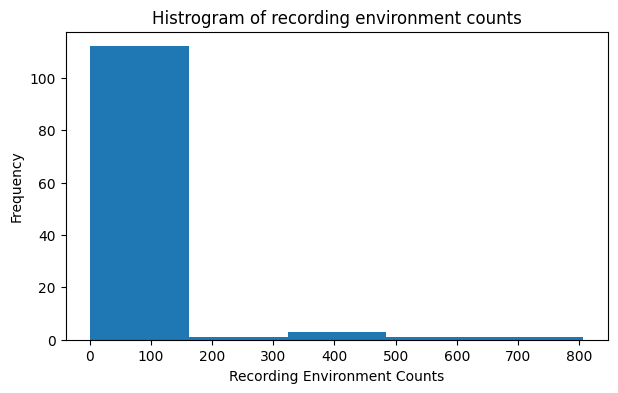

In [14]:
plt.title("Histrogram of recording environment counts")
rec_env_counts.plot.hist(bins=5, figsize=(7, 4))
plt.xlabel("Recording Environment Counts")
plt.show()

You can use the following commands to tweak your plot: 

- `plt.title(TITLE)` to add a title
- `plt.xlabel(X_LABEL)` to add a label for the horizontal axis
- `plt.ylabel(Y_LABEL)` to add a label for the vertical axis
- `plt.xticks(LIST_OF_INDICES, LIST_OF_DISPLAYED_NAMES_IN_PLOT)` to change the default ticks on the x axis

### Column transformation

Quite often, we want to introduce new columns based on values in another column. 

To create a new column based on an existing one, we can use the method ```.transform(function)```. Let's create a new column that is True if one of the target classes is related to or involves water:

In [15]:
def is_water(target_classes: str):
    return 'water' in target_classes or 'toilet' in target_classes or 'coffee' in target_classes

metadata["involves_water"] = metadata["target_classes"].transform(is_water)
metadata["involves_water"].value_counts()

involves_water
False    2022
True     1053
Name: count, dtype: int64

In [16]:
metadata.loc[metadata["involves_water"] == True, ["target_classes", "recording_environment"]]

,target_classes,recording_environment
filename,,
004938.wav,footsteps;running_water;coffee_machine,office
004289.wav,running_water;light_switch;footsteps,bathroom
003062.wav,running_water;cutlery_dishes;wardrobe_drawer_o...,kitchen
000535.wav,door_open_close;light_switch;cutlery_dishes;ru...,kitchen
004013.wav,door_open_close;light_switch;running_water;toi...,bathroom
...,...,...
002370.wav,phone_ringing;footsteps;door_open_close;runnin...,kitchen
003775.wav,light_switch;door_open_close;footsteps;coffee_...,kitchen
003694.wav,running_water;cutlery_dishes;door_open_close,kitchen


## 4. Loading Annotations

You can load the annotations in the same way as the metadata, i.e.:

In [17]:
annotations = pd.read_csv(os.path.join(PATH_TO_DATASET, "annotations.csv"))
annotations[["filename", "annotator_id", "onset", "offset", "annotation", "is_own_recording"]].head(n=3)

,filename,annotator_id,onset,offset,annotation,is_own_recording
0,002999.wav,6266065926778734288049971227397498250419692068...,21.084444,21.795556,door_open_close,True
1,005146.wav,4738332388041469681443539930383360524770125556...,10.919846,11.175414,phone_ringing,False
2,003804.wav,8690555271234787183769011537482691030935887992...,0.983507,15.977681,running_water,False


### Basic table properties

In [18]:
print("DataFrame shape: ", annotations.shape)
print("DataFrame rows: ", len(annotations.index))
print("DataFrame columns: ", len(annotations.columns))
print("DataFrame column names: ", annotations.columns.to_list())

DataFrame shape:  (23213, 6)
DataFrame rows:  23213
DataFrame columns:  6
DataFrame column names:  ['filename', 'annotator_id', 'annotation', 'onset', 'offset', 'is_own_recording']


### Annotation counts and durations

We can also count the number of annotations per file using `.value_counts()` and apply some simple summary statistics. 

In [19]:
annotations_per_file = annotations["filename"].value_counts()

print("Min: ", annotations_per_file.min())
print("Max: ", annotations_per_file.max())
print("Mean: ", annotations_per_file.mean())
print("Median: ", annotations_per_file.median())

Min:  1
Max:  52
Mean:  7.548943089430894
Median:  6.0


Or we can plot the distribution of annotations per file:

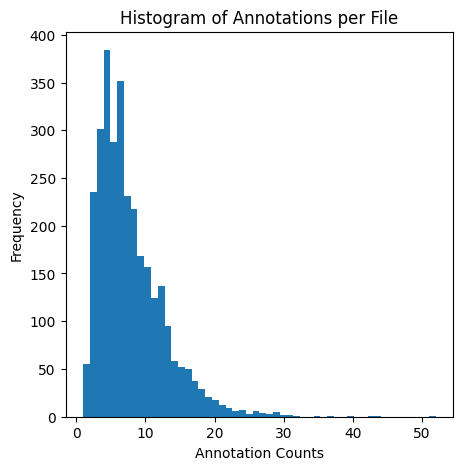

In [20]:
plt.title("Histogram of Annotations per File")
annotations_per_file.plot.hist(bins=annotations_per_file.max(), figsize=(5, 5))
plt.xlabel("Annotation Counts")
plt.show()

It might be also of interest to look at the length of the annotated segments. We can compute this by subtracting the onset from the offset time for each annotation. 
Let's add a new column to the annotations data frame that contains the segment length in seconds.

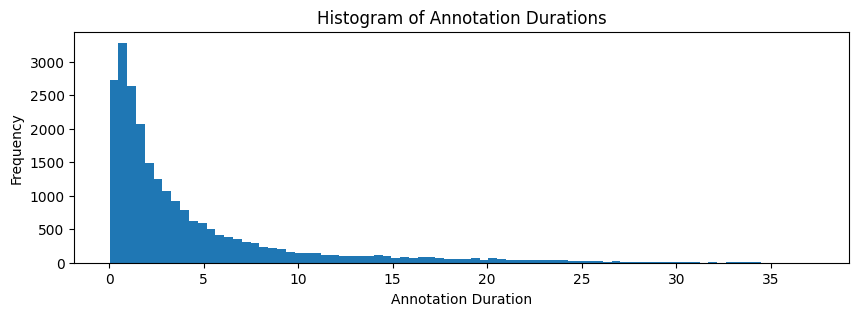

In [21]:
annotations["duration"] = annotations["offset"] - annotations["onset"]
annotations["duration"].plot.hist(bins=80, figsize=(10, 3))
plt.xlabel("Annotation Duration")
plt.ylabel("Frequency")
plt.title("Histogram of Annotation Durations")
plt.show()

### Grouping

Quite often, we're interested in comparing statistics for different groups. 

We can group the table by distinct values in a column using `.groupby(COLUMN_NAME)`and compute statistics for each group. Next, we compute the median annotation duration for each annotator:

In [22]:
median_duration_per_annotator = annotations.groupby("annotator_id")["duration"].median()
median_duration_per_annotator.head(n=3)

annotator_id
286330067860903610926652848251538243869553344779428654848421259154987376120     3.212190
1119408104570139724301764673543749248915039488587866599424462987734777928999    3.776206
1712486454456251377506402675901368184416314865018504410990692461977861695897    1.403697
Name: duration, dtype: float64

### Merging two Tables

We might want to concatenate the recording environment associated with each audio file (in `metadata`) to the annotations.

In [23]:
metadata[["recording_environment"]].head(3)

,recording_environment
filename,
005490.wav,living_room
004058.wav,living_room
005682.wav,hallway;kitchen


We can use ```merge``` for this as follows:

In [24]:
annotations_meta = annotations.merge(metadata, on="filename", how="left", suffixes=('', '_metadata'))
annotations_meta[["filename", "duration", "annotation", "recording_environment"]].head(n=3)

,filename,duration,annotation,recording_environment
0,002999.wav,0.711111,door_open_close,toilet
1,005146.wav,0.255568,phone_ringing,bedroom
2,003804.wav,14.994174,running_water,kitchen


- We use the `on` parameter as column to join on. 
- The `suffix` parameter is used to handle column name collisions when merging two DataFrames with overlapping column names.
- The parameter `how` specifies how to merge. Merging dataframes is similar to performing SQL joins.

## 5. Audio Features

The dataset package includes precomputed features and annotations that are already aggregated over one second windows with a hop size of 0.5 seconds. You may want to directly use the aligned annotation array.

```
MLPC2026_dataset_development.zip
|-- metadata.csv
|-- annotations.csv
\-- audio_features/       <-- load this
    |-- 000001.npz
    |-- 000002.npz
    \-- ...
```

Load the feature-annotation files with:

In [25]:
import os
import numpy as np

features_dir = os.path.join(PATH_TO_DATASET, "audio_features")
npz_files = sorted(
    [f for f in os.listdir(features_dir) if f.endswith(".npz")]
 )

print(f"Found {len(npz_files)} feature files in {features_dir}")
print("First 5 files:", npz_files[:5])

# Map from stem (e.g., '000001') to absolute file path for quick lookup
feature_file_map = {
    os.path.splitext(filename)[0]: os.path.join(features_dir, filename)
    for filename in npz_files
}

def load_feature_file(file_id: str):
    """Lazy-load a single .npz file by ID (without .npz extension)."""
    path = feature_file_map[file_id]
    return np.load(path, allow_pickle=True)

# Example: only this file is loaded now
example_file_id = next(iter(feature_file_map))
example_features = load_feature_file(example_file_id)

Found 3075 feature files in MLPC2026_dataset_development/audio_features
First 5 files: ['000001.npz', '000002.npz', '000003.npz', '000004.npz', '000005.npz']


The result is a dictionary holding the features and labels as numpy arrays:

In [26]:
example_features = dict(example_features)
example_features.keys() #, example_features

dict_keys(['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', 'non_target_classes'

In [27]:
example_features["annotations"].shape # [T, C, A]

(61, 15, 2)

## 6. Annotation Visualizations

The `annotations` array in each `.npz` file has shape **[T, C, A]** - time steps $\times$ classes $\times$ annotators. Each value represents the proportional overlap between an annotation event and the corresponding time segment.

Below we compare how different annotators labelled the same recording using image plots (one per annotator).

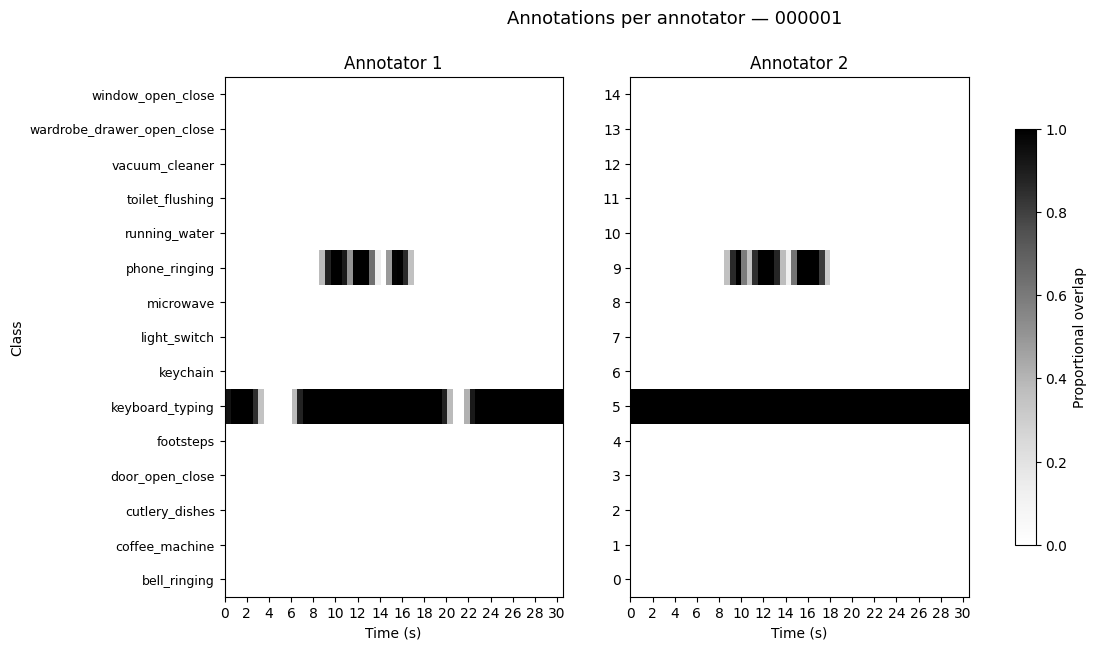

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Load annotations for the example file
data = dict(load_feature_file(example_file_id))
ann = data["annotations"]          # shape: [T, C, A]
T, C, A = ann.shape

# Class names
class_names = sorted(annotations["annotation"].unique().tolist())
if len(class_names) != C:
    class_names = [f"Class {i}" for i in range(C)]

# Time axis in seconds (0.5 s hop size)
hop = 0.5

# Plot one image per annotator side by side
fig, axes = plt.subplots(
    1, A,
    figsize=(6 * A, max(3, C * 0.45))
)
if A == 1:
    axes = [axes]

for a_idx, ax in enumerate(axes):
    im = ax.imshow(
        ann[:, :, a_idx].T,          # shape [C, T] for imshow
        aspect="auto",
        origin="lower",
        vmin=0, vmax=1,
        cmap="Greys",
        extent=[0, T * hop, -0.5, C - 0.5],
    )
    ax.set_title(f"Annotator {a_idx + 1}", fontsize=12)
    ax.set_xlabel("Time (s)")
    ax.set_yticks(range(C))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))

axes[0].set_yticklabels(class_names, fontsize=9)
axes[0].set_ylabel("Class")

cbar = fig.colorbar(im, ax=axes, shrink=0.8, label="Proportional overlap")
fig.suptitle(f"Annotations per annotator — {example_file_id}", fontsize=13)
plt.show()

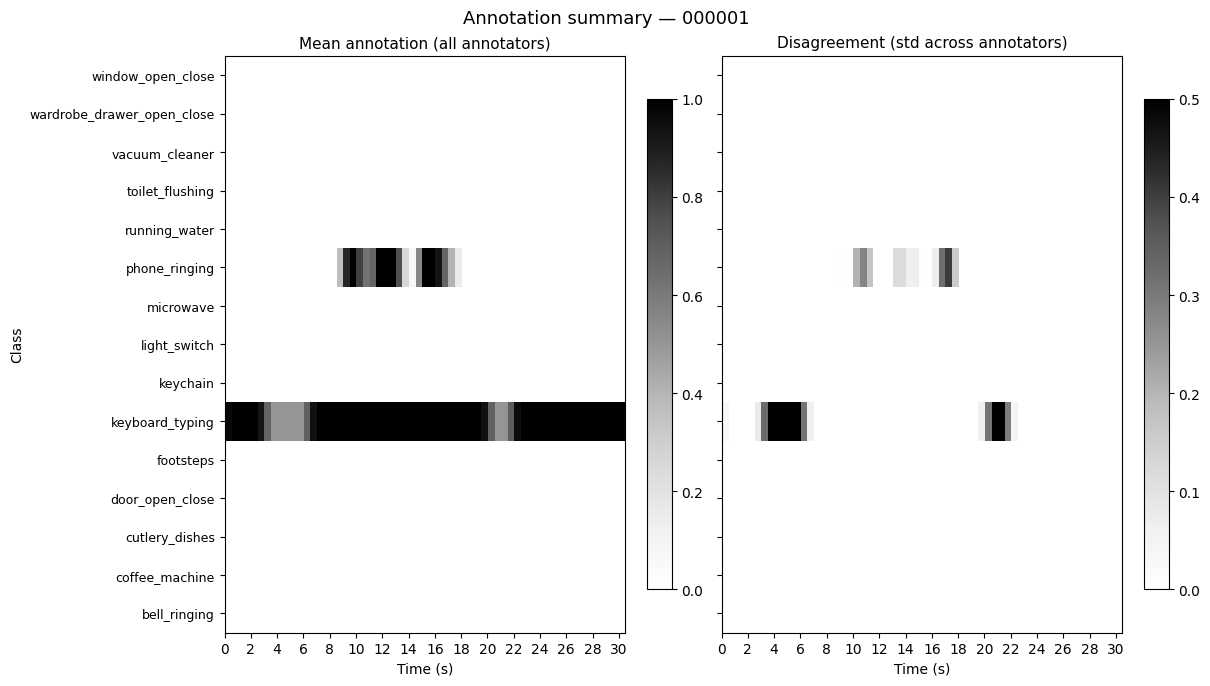

In [29]:
# Mean annotation & inter-annotator disagreement (std)
ann_mean = ann.mean(axis=2)   # [T, C]
ann_std  = ann.std(axis=2)    # [T, C]

fig, axes = plt.subplots(1, 2, figsize=(12, max(3, C * 0.45)), sharey=True, constrained_layout=True)

for ax, matrix, title in zip(
    axes,
    [ann_mean, ann_std],
    ["Mean annotation (all annotators)", "Disagreement (std across annotators)"],
):
    im = ax.imshow(
        matrix.T,
        aspect="auto",
        origin="lower",
        vmin=0, vmax=matrix.max() or 1,
        cmap="Greys",
        extent=[0, T * hop, -0.5, C - 0.5],
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_yticks(range(C))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    fig.colorbar(im, ax=ax, shrink=0.85)

axes[0].set_yticklabels(class_names, fontsize=9)
axes[0].set_ylabel("Class")
fig.suptitle(f"Annotation summary — {example_file_id}", fontsize=13)
plt.show()

## 7. Class Prevalence

How active is each class on average? We aggregate the annotation array over time and annotators - using `np.nanmean` to ignore annotators who did not annotate a given file.

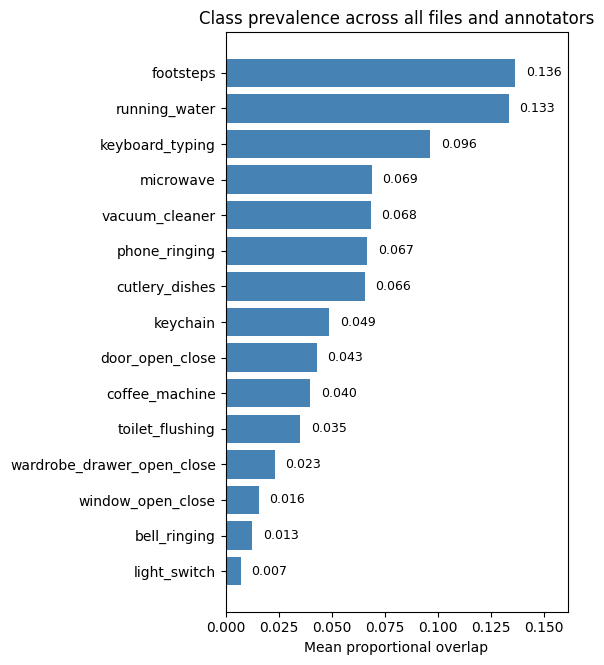

In [30]:
# Collect annotation arrays across all files
all_ann_flat = []   # list of [T*A, C] arrays (one per file)

for file_id in feature_file_map:
    d = load_feature_file(file_id)
    if "annotations" not in d:
        continue
    ann = d["annotations"].astype(float)   # [T, C, A]
    T, C, A = ann.shape
    all_ann_flat.append(ann.transpose(0, 2, 1).reshape(-1, C))   # [T*A, C]

stacked    = np.concatenate(all_ann_flat, axis=0)   # [N, C]
prevalence = np.nanmean(stacked, axis=0)             # [C]

# Class names
class_names = sorted(annotations["annotation"].unique().tolist())
if len(class_names) != len(prevalence):
    class_names = [f"Class {i}" for i in range(len(prevalence))]

# Sort bars by prevalence (highest first)
order = np.argsort(prevalence)[::-1]
sorted_prev = prevalence[order]
sorted_names = [class_names[i] for i in order]

fig, ax = plt.subplots(figsize=(6, max(4, len(class_names) * 0.45)))
ax.barh(range(len(sorted_prev)), sorted_prev, color="steelblue")
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names)
ax.invert_yaxis()
ax.set_xlabel("Mean proportional overlap")
ax.set_xlim(0, sorted_prev.max() * 1.18)
ax.set_title("Class prevalence across all files and annotators")
for i, v in enumerate(sorted_prev):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Annotator Agreement

One way to measure the agreement between annotators is using the **Jaccard similarity** between the sets of active annotations:

$$J = \frac{|\text{all annotators active}|}{|\text{at least one annotator active}|} = \frac{\text{intersection}}{\text{union}}$$

It is defined as the Intersection over Union (IoU).
Here, only cells where at least one annotator marked something active are considered. A value of 1 means all annotators agreed on every active event; 0 means no overlap at all.

In [31]:
agreement_rates = []

for file_id in feature_file_map:
    d = load_feature_file(file_id)
    if "annotations" not in d or d["annotations"].shape[2] < 2:
        continue
    binary = d["annotations"] > 0             # [T, C, A]

    intersection = binary.all(axis=2).sum()   # cells all annotators marked active
    union = binary.any(axis=2).sum()   # cells at least one annotator marked active
    if union == 0:
        continue
    agreement_rates.append(intersection / union)

agreement_rates = np.array(agreement_rates)
print(f"Jaccard agreement (intersection / union of active cells)")
print(f"  Mean  : {agreement_rates.mean():.1%}")
print(f"  Std   : {agreement_rates.std():.1%}")
print(f"  Min   : {agreement_rates.min():.1%}")
print(f"  Max   : {agreement_rates.max():.1%}")

Jaccard agreement (intersection / union of active cells)
  Mean  : 75.0%
  Std   : 21.0%
  Min   : 0.0%
  Max   : 100.0%


## 9. Audio Feature Visualizations

Each `.npz` file contains pre-computed features extracted on **32 ms frames** and then aggregated over **1 s windows** (hop = 0.5 s). For each feature type four aggregation statistics are stored: `*_mean`, `*_std`, `*_min`, `*_max`.

Available features: `zcr`, `melspect`, `mfcc`, `mfcc_d`, `mfcc_d2`, `flux`, `flatness`, `centroid`, `bandwidth`, `contrast`, `rolloff_low`, `rolloff_high`, `energy`, `power`.

### Feature matrix (mel spectrogram)

`melspect_mean` gives the mean mel-band energy per window - analogous to a standard mel spectrogram, but at 0.5 s resolution.

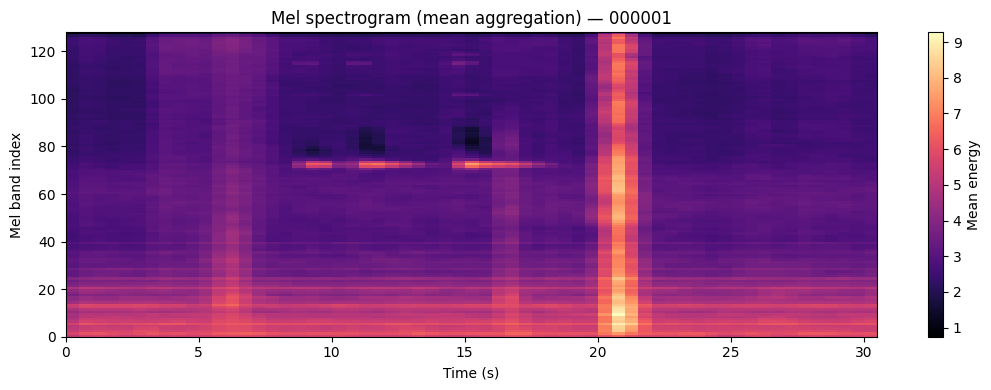

In [32]:
data = dict(load_feature_file(example_file_id))
hop  = 0.5   # seconds

melspect = data["melspect_mean"]   # [T, n_mels]
T_mel = melspect.shape[0]

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(
    melspect.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[0, T_mel * hop, 0, melspect.shape[1]],
    cmap="magma",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mel band index")
ax.set_title(f"Mel spectrogram (mean aggregation) — {example_file_id}")
fig.colorbar(im, ax=ax, label="Mean energy")
plt.tight_layout()
plt.show()

## 10. Raw Audio Waveforms

Instead of (pre-computed) audio features, we can also have a look at the raw audio waveforms. For this, the ```librosa``` library can be helpful.

Before we can load the files, make sure to download the ```MLPC2026_dataset_development_raw_audio.zip``` file and extract it, which should give you the following:
```
MLPC2026_dataset_development_raw_audio       <-- load this
|-- 000001.wav
|-- 000002.wav
\-- ...
```

Now, set the path to the raw audio files:

In [33]:
PATH_TO_AUDIO = 'MLPC2026_dataset_development_raw_audio'

We can load the audio files with ```librosa.load``` as follows:

In [34]:
import os
import librosa
import numpy as np

wav_files = sorted(
    [f for f in os.listdir(PATH_TO_AUDIO) if f.endswith(".wav")]
 )

print(f"Found {len(wav_files)} audio files in {PATH_TO_AUDIO}")
print("First 5 files:", wav_files[:5])

# Map from stem (e.g., '000001') to absolute file path again for quick lookup, as for features
audio_file_map = {
    os.path.splitext(filename)[0]: os.path.join(PATH_TO_AUDIO, filename)
    for filename in wav_files
}

def load_audio_file(file_id: str, sr: int = 22050):
    """Lazy-load a single .wav file by ID (without .wav extension)."""
    path = audio_file_map[file_id]
    y, sr = librosa.load(path, sr=sr)
    return y, sr

# Load one exemplary audio file
example_file_id = next(iter(audio_file_map))
example_audio, sr = load_audio_file(example_file_id)

Found 384 audio files in MLPC2026_dataset_development_raw_audio
First 5 files: ['000001.wav', '000002.wav', '000003.wav', '000004.wav', '000005.wav']


The result of ```librosa.load``` is a ```numpy``` array. 
We here loaded the files with a sampling rate of 22050 (```sr = None``` loads the audio file with its original sampling rate). 

Let us look at the shape of the audio file; because we look at mono signals here, it is a one dimensional array. The length depends on the length of the audio and the sampling rate:

In [35]:
print(example_audio.shape)

(688196,)


### Raw Audio Visualization

We can also use ```librosa``` to visualize the waveform, e.g.:

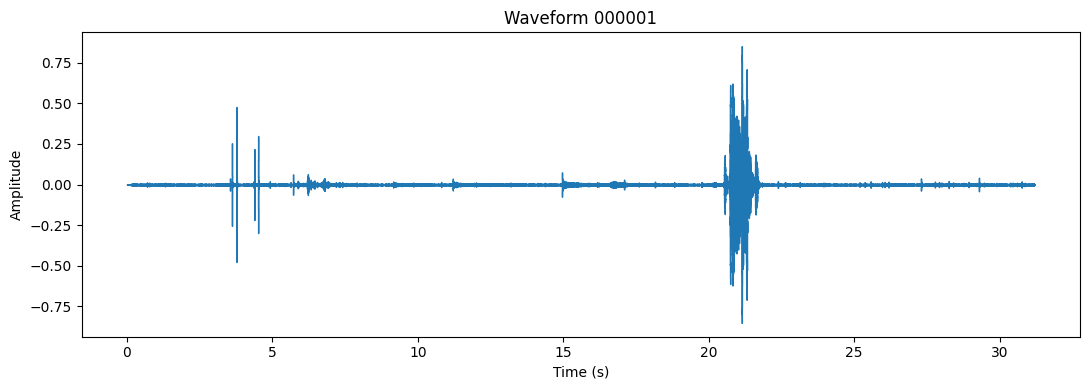

In [36]:
import matplotlib.pyplot as plt

# First, load exemplary audio file
y, sr = load_audio_file(example_file_id)

# Now use matplotlib and ```librosa.display.waveshow``` to visualize audio content
fig, ax = plt.subplots(figsize=(11, 4))
librosa.display.waveshow(y, sr=sr, ax=ax)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Waveform {example_file_id}")
plt.tight_layout()
plt.show()